# Fuzzy AHP Priority Ranking - Sample Development Pipeline

## Decision Support Stage

This notebook documents the Fuzzy AHP calculation pipeline for SentiRank. Phase 10C uses sample development judgements only to validate template conversion, Fuzzy AHP calculation, output export, and figure generation.

**Important:** outputs in this notebook are marked `sample_development_only` and `not_final_expert_judgement`. They are not final Fuzzy AHP weights and must not be used as thesis ranking results.

## Fuzzy AHP Role in SentiRank

Fuzzy AHP is compared with standard AHP because expert judgement can be uncertain. It represents linguistic pairwise judgement with triangular fuzzy numbers and then defuzzifies weights using the centroid method.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "ml-service").exists()
            and (candidate / "datasets").exists()
            and (candidate / "docs").exists()
        ):
            return candidate
    raise RuntimeError("Project root not found.")


PROJECT_ROOT = find_project_root()
ML_SERVICE_DIR = PROJECT_ROOT / "ml-service"
TEMPLATE_DIR = PROJECT_ROOT / "docs" / "templates" / "ahp"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ML_SERVICE_DIR:", ML_SERVICE_DIR)

PROJECT_ROOT: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank
ML_SERVICE_DIR: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\ml-service


In [2]:
def load_json(path: Path):
    if not path.exists():
        print(f"Missing JSON: {path}")
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def load_csv(path: Path):
    if not path.exists():
        print(f"Missing CSV: {path}")
        return None
    return pd.read_csv(path)


def display_image(path: Path) -> None:
    if not path.exists():
        print(f"Missing figure: {path}")
        return
    display(Image(filename=str(path)))


def run_ml_script(script_name: str) -> None:
    command = [sys.executable, "scripts/" + script_name]
    result = subprocess.run(
        command,
        cwd=ML_SERVICE_DIR,
        text=True,
        capture_output=True,
        check=False,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Script failed: {script_name}")

## Final Candidate Criteria

The same five criteria used by AHP are used by Fuzzy AHP so that both methods can be compared directly.

In [3]:
criteria_payload = load_json(TEMPLATE_DIR / "final_criteria_for_ahp.json")
if criteria_payload:
    criteria_df = pd.DataFrame(criteria_payload["criteria"])
    display(criteria_df[["criterion_id", "criterion_name", "description", "source_labels", "expert_validation_required"]])

,criterion_id,criterion_name,description,source_labels,expert_validation_required
0,C1,"Features, Content & Audio Experience",Issues or improvement priorities related to mu...,"[Features & Content, Audio Quality]",True
1,C2,App Reliability & Usability,Issues or improvement priorities related to ap...,"[Performance & Stability, UI/UX]",True
2,C3,Ads Experience,Issues or improvement priorities related to ad...,[Ads Experience],True
3,C4,Subscription & Pricing,Issues or improvement priorities related to pr...,[Subscription & Pricing],True
4,C5,Account/Login,Issues or improvement priorities related to ac...,[Account/Login],True


## Sample Fuzzy AHP Input

The sample input contains exactly 10 fuzzy pairwise comparisons. Numeric TFN columns are the source of truth for the script.

In [4]:
fuzzy_sample_input = TEMPLATE_DIR / "sample_development" / "fuzzy_ahp_pairwise_sample_development.csv"
fuzzy_input_df = load_csv(fuzzy_sample_input)
if fuzzy_input_df is not None:
    display(fuzzy_input_df)
    print("Pairwise comparisons:", len(fuzzy_input_df))

,respondent_id,respondent_role,comparison_id,criterion_a,criterion_b,preferred_criterion,linguistic_scale,fuzzy_l,fuzzy_m,fuzzy_u,fuzzy_value_a_over_b,justification,run_label,not_final_expert_judgement
0,SAMPLE_DEV,Development sample,P01,"Features, Content & Audio Experience",App Reliability & Usability,criterion_b,moderate,0.25,0.333333,0.5,"(0.25, 0.3333333333333333, 0.5)","Sample development only, not final expert judg...",sample_development_only,True
1,SAMPLE_DEV,Development sample,P02,"Features, Content & Audio Experience",Ads Experience,criterion_a,moderate,2.00,3.000000,4.0,"(2, 3, 4)","Sample development only, not final expert judg...",sample_development_only,True
2,SAMPLE_DEV,Development sample,P03,"Features, Content & Audio Experience",Subscription & Pricing,equal,equal,1.00,1.000000,1.0,"(1, 1, 1)","Sample development only, not final expert judg...",sample_development_only,True
3,SAMPLE_DEV,Development sample,P04,"Features, Content & Audio Experience",Account/Login,criterion_a,moderate,2.00,3.000000,4.0,"(2, 3, 4)","Sample development only, not final expert judg...",sample_development_only,True
4,SAMPLE_DEV,Development sample,P05,App Reliability & Usability,Ads Experience,criterion_a,extreme,8.00,9.000000,9.0,"(8, 9, 9)","Sample development only, not final expert judg...",sample_development_only,True
5,SAMPLE_DEV,Development sample,P06,App Reliability & Usability,Subscription & Pricing,criterion_a,moderate,2.00,3.000000,4.0,"(2, 3, 4)","Sample development only, not final expert judg...",sample_development_only,True
6,SAMPLE_DEV,Development sample,P07,App Reliability & Usability,Account/Login,criterion_a,extreme,8.00,9.000000,9.0,"(8, 9, 9)","Sample development only, not final expert judg...",sample_development_only,True
7,SAMPLE_DEV,Development sample,P08,Ads Experience,Subscription & Pricing,criterion_b,moderate,0.25,0.333333,0.5,"(0.25, 0.3333333333333333, 0.5)","Sample development only, not final expert judg...",sample_development_only,True
8,SAMPLE_DEV,Development sample,P09,Ads Experience,Account/Login,equal,equal,1.00,1.000000,1.0,"(1, 1, 1)","Sample development only, not final expert judg...",sample_development_only,True
9,SAMPLE_DEV,Development sample,P10,Subscription & Pricing,Account/Login,criterion_a,moderate,2.00,3.000000,4.0,"(2, 3, 4)","Sample development only, not final expert judg...",sample_development_only,True


Pairwise comparisons: 10


## Run Sample Fuzzy AHP Calculation

This cell runs only the sample-development script. It writes to `datasets/outputs/eda/07_fuzzy_ahp/sample_development/` and does not create final `fuzzy_ahp_weights.csv` or ranking outputs.

In [5]:
run_ml_script("calculate_fuzzy_ahp_from_expert_judgement.py")

Fuzzy AHP sample weights written to: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\07_fuzzy_ahp\sample_development\fuzzy_ahp_weights_sample_development.json
Fuzzy AHP sample modal CR: 0.0000000000
Fuzzy AHP sample figure written to: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\docs\figures\07_fuzzy_ahp\sample_development\fuzzy_ahp_weights_sample_development.png



## Sample Fuzzy AHP Outputs

The outputs below show fuzzy weights, defuzzified/normalized weights, and modal consistency ratio.

In [6]:
FUZZY_OUTPUT_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "07_fuzzy_ahp" / "sample_development"
FUZZY_FIGURE_DIR = PROJECT_ROOT / "docs" / "figures" / "07_fuzzy_ahp" / "sample_development"

weights_df = load_csv(FUZZY_OUTPUT_DIR / "fuzzy_ahp_weights_sample_development.csv")
if weights_df is not None:
    display(weights_df.sort_values("rank"))

modal_consistency = load_json(FUZZY_OUTPUT_DIR / "fuzzy_ahp_modal_consistency_sample_development.json")
if modal_consistency:
    display(pd.DataFrame([modal_consistency]))

matrix_payload = load_json(FUZZY_OUTPUT_DIR / "fuzzy_ahp_pairwise_matrix_sample_development.json")
if matrix_payload:
    display(pd.DataFrame(matrix_payload["modal_crisp_matrix"]))

,criterion_id,criterion_name,fuzzy_l,fuzzy_m,fuzzy_u,defuzzified_weight,normalized_weight,rank,run_label,is_sample,not_final_expert_judgement
1,C2,App Reliability & Usability,0.368590,0.529412,0.726476,0.541493,0.519544,1,sample_development_only,True,True
0,C1,"Features, Content & Audio Experience",0.121589,0.176471,0.262614,0.186891,0.179316,2,sample_development_only,True,True
3,C4,Subscription & Pricing,0.121589,0.176471,0.262614,0.186891,0.179316,3,sample_development_only,True,True
2,C3,Ads Experience,0.045001,0.058824,0.086630,0.063485,0.060912,4,sample_development_only,True,True
4,C5,Account/Login,0.045001,0.058824,0.086630,0.063485,0.060912,5,sample_development_only,True,True


,run_label,is_sample,not_final_expert_judgement,consistency_ratio_modal,consistency_threshold,is_consistent_modal,warnings
0,sample_development_only,True,True,0.0,0.1,True,[]


,0,1,2,3,4
0,1.000000,0.333333,3.0,1.000000,3.0
1,3.000000,1.000000,9.0,3.000000,9.0
2,0.333333,0.111111,1.0,0.333333,1.0
3,1.000000,0.333333,3.0,1.000000,3.0
4,0.333333,0.111111,1.0,0.333333,1.0


## Sample Fuzzy AHP Weight Figure

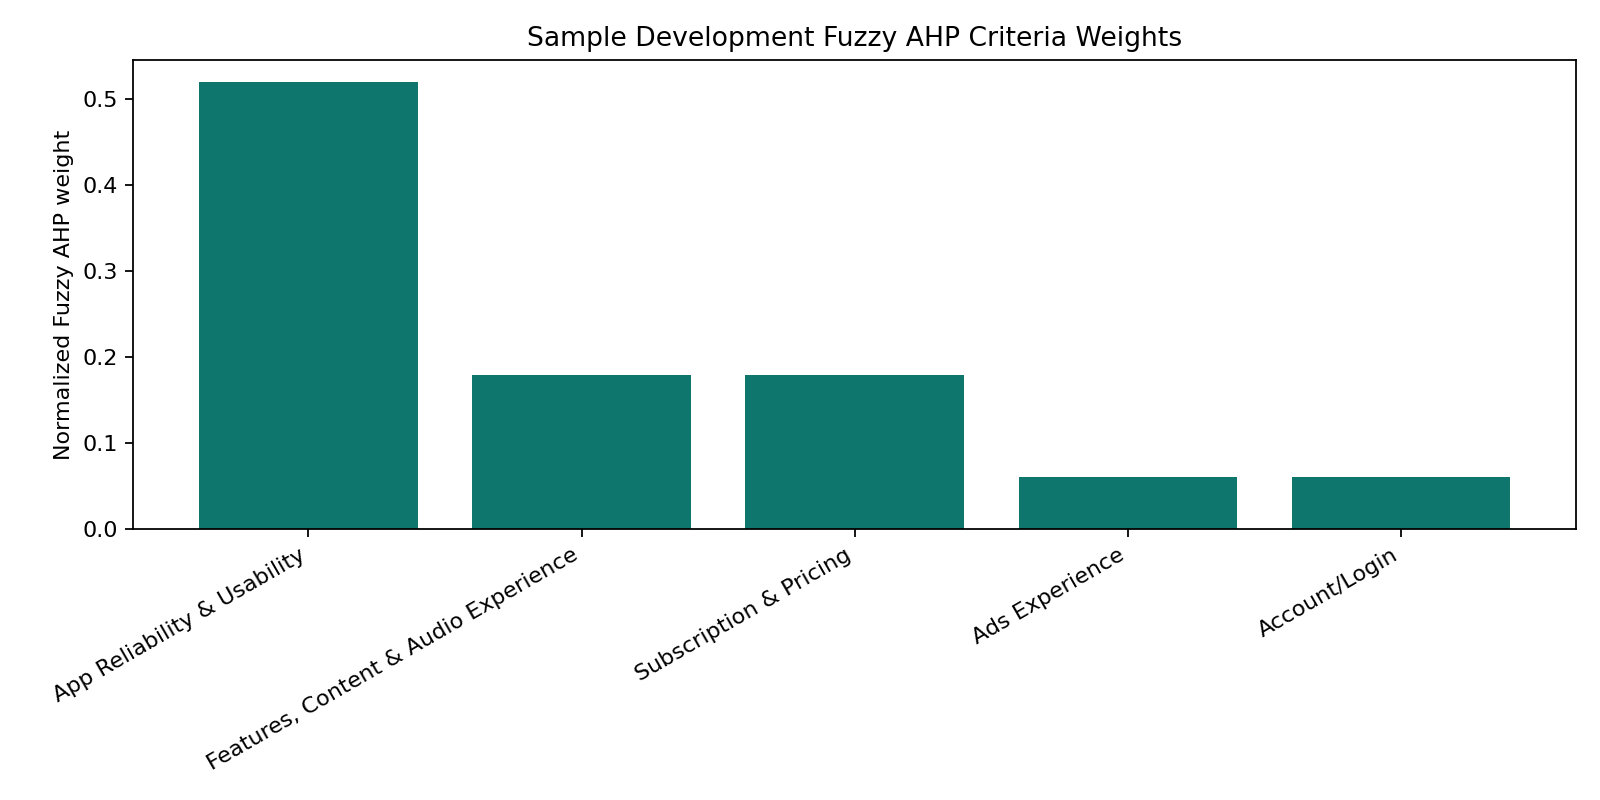

In [7]:
display_image(FUZZY_FIGURE_DIR / "fuzzy_ahp_weights_sample_development.png")

## Interpretation Notes

- The sample modal CR is expected to be approximately `0` because modal values follow the consistent development AHP matrix.
- Real expert judgement is still required before final Fuzzy AHP weighting.
- Final Fuzzy AHP weights and priority rankings are intentionally not generated in Phase 10C.

## Phase 10D: Expert Judgement Validation and Aggregation

Before final Fuzzy AHP calculation, real expert judgement files must be validated and aggregated. The cells below use the sample-development input by default, so the generated reports are workflow checks only and are not final expert judgement.

In [8]:
run_ml_script("validate_fuzzy_ahp_expert_judgement.py")
run_ml_script("aggregate_fuzzy_ahp_expert_judgement.py")

Fuzzy AHP validation report JSON: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\07_fuzzy_ahp\validation\fuzzy_ahp_expert_judgement_validation_report.json
Fuzzy AHP validation report CSV: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\07_fuzzy_ahp\validation\fuzzy_ahp_expert_judgement_validation_report.csv
Can calculate: True
Valid respondents: 1
Invalid respondents: 0

Fuzzy AHP aggregated judgement JSON: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\07_fuzzy_ahp\aggregated\fuzzy_ahp_aggregated_pairwise_judgement.json
Fuzzy AHP aggregated judgement CSV: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank\datasets\outputs\eda\07_fuzzy_ahp\aggregated\fuzzy_ahp_aggregated_pairwise_judgement.csv
Total respondents: 1
Aggregated comparisons: 10



In [9]:
FUZZY_VALIDATION_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "07_fuzzy_ahp" / "validation"
FUZZY_AGGREGATED_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "07_fuzzy_ahp" / "aggregated"

validation_report = load_json(FUZZY_VALIDATION_DIR / "fuzzy_ahp_expert_judgement_validation_report.json")
if validation_report:
    display(pd.DataFrame([{
        "run_label": validation_report["run_label"],
        "is_sample": validation_report["is_sample"],
        "can_calculate": validation_report["can_calculate"],
        "total_rows": validation_report["total_rows"],
        "total_respondents": validation_report["total_respondents"],
        "valid_respondent_count": validation_report["valid_respondent_count"],
        "invalid_respondent_count": validation_report["invalid_respondent_count"],
        "issue_count": validation_report["issue_count"],
    }]))
    if validation_report["issues"]:
        display(pd.DataFrame(validation_report["issues"]))

aggregated_df = load_csv(FUZZY_AGGREGATED_DIR / "fuzzy_ahp_aggregated_pairwise_judgement.csv")
if aggregated_df is not None:
    display(aggregated_df)

,run_label,is_sample,can_calculate,total_rows,total_respondents,valid_respondent_count,invalid_respondent_count,issue_count
0,sample_development_only,True,True,10,1,1,0,0


,run_label,is_sample,not_final_expert_judgement,comparison_id,criterion_a,criterion_b,fuzzy_l,fuzzy_m,fuzzy_u,fuzzy_value_a_over_b,respondent_count,aggregation_method
0,sample_development_only,True,True,P01,"Features, Content & Audio Experience",App Reliability & Usability,0.25,0.333333,0.5,"(0.25, 0.3333333333333333, 0.5)",1,component_wise_geometric_mean
1,sample_development_only,True,True,P02,"Features, Content & Audio Experience",Ads Experience,2.00,3.000000,4.0,"(2.0, 3.0000000000000004, 4.0)",1,component_wise_geometric_mean
2,sample_development_only,True,True,P03,"Features, Content & Audio Experience",Subscription & Pricing,1.00,1.000000,1.0,"(1.0, 1.0, 1.0)",1,component_wise_geometric_mean
3,sample_development_only,True,True,P04,"Features, Content & Audio Experience",Account/Login,2.00,3.000000,4.0,"(2.0, 3.0000000000000004, 4.0)",1,component_wise_geometric_mean
4,sample_development_only,True,True,P05,App Reliability & Usability,Ads Experience,8.00,9.000000,9.0,"(7.999999999999998, 9.000000000000002, 9.00000...",1,component_wise_geometric_mean
5,sample_development_only,True,True,P06,App Reliability & Usability,Subscription & Pricing,2.00,3.000000,4.0,"(2.0, 3.0000000000000004, 4.0)",1,component_wise_geometric_mean
6,sample_development_only,True,True,P07,App Reliability & Usability,Account/Login,8.00,9.000000,9.0,"(7.999999999999998, 9.000000000000002, 9.00000...",1,component_wise_geometric_mean
7,sample_development_only,True,True,P08,Ads Experience,Subscription & Pricing,0.25,0.333333,0.5,"(0.25, 0.3333333333333333, 0.5)",1,component_wise_geometric_mean
8,sample_development_only,True,True,P09,Ads Experience,Account/Login,1.00,1.000000,1.0,"(1.0, 1.0, 1.0)",1,component_wise_geometric_mean
9,sample_development_only,True,True,P10,Subscription & Pricing,Account/Login,2.00,3.000000,4.0,"(2.0, 3.0000000000000004, 4.0)",1,component_wise_geometric_mean


### Phase 10D Note

The aggregated Fuzzy AHP pairwise judgement is an intermediate artifact only. It is not a Fuzzy AHP weight file and it is not a final ranking. Final Fuzzy AHP calculation must wait for validated real expert judgement data.